# Radiative-Convective Equilibrium with Pure Python Emanuel Convection

This notebook demonstrates a radiative-convective equilibrium simulation using the **pure Python** implementation of the Emanuel convection scheme. This allows for easier debugging and inspection of the convective logic.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta
from sympl import PlotFunctionMonitor, AdamsBashforth, NetCDFMonitor, set_backend
from climt import (
    SimplePhysics, get_default_state, UnytBackend, UnytTimeDelta,
    EmanuelConvectionPythonV3, RRTMGShortwave, RRTMGLongwave, SlabSurface
)
from sympl import get_backend

# # # Set the active backend to Unyt for speed
set_backend(UnytBackend())
print(f"Active backend: {type(get_backend()).__name__}")

Active backend: UnytBackend


In [4]:
get_backend().get_container_type()

climt._core.unyt_backend.UnytStateContainer

## Utility Helpers

In [5]:
def get_data(obj):
    """Helper to get numpy array from either DataArray or UnytStateContainer."""
    if hasattr(obj, 'values'):
        return obj.values
    elif hasattr(obj, 'data'):
        return np.asarray(obj.data)
    return np.asarray(obj)

def to_units(obj, units):
    """Helper to convert units for either DataArray or UnytStateContainer."""
    if hasattr(obj, 'to_units'):
        return obj.to_units(units)
    elif hasattr(obj, 'data'):
        target_units = units.replace('mbar', 'hPa')
        sanitized_units = target_units.replace("^", "**").replace(" ", "*")
        return obj.data.to(sanitized_units)
    return obj

## Plotting Function

In [6]:
def plot_function(fig, state):
    fig.clf()
    ax = fig.add_subplot(2, 2, 1)
    
    heating_rate = to_units(state['air_temperature_tendency_from_convection'], 'degK day^-1')
    pressure = to_units(state['air_pressure'], 'mbar')
    
    ax.plot(get_data(heating_rate).flatten(), get_data(pressure).flatten(), '-o')
    ax.set_title('Conv. heating rate')
    ax.set_xlabel('K/day')
    ax.set_ylabel('millibar')
    ax.grid()
    ax.invert_yaxis()

    ax = fig.add_subplot(2, 2, 2)
    temp = state['air_temperature']
    ax.plot(get_data(temp).flatten(), get_data(pressure).flatten(), '-o')
    ax.set_title('Air temperature')
    ax.set_xlabel('K')
    ax.grid()
    ax.invert_yaxis()

    ax = fig.add_subplot(2, 2, 3)
    lw_tendency = state['air_temperature_tendency_from_longwave']
    sw_tendency = state['air_temperature_tendency_from_shortwave']
    ax.plot(get_data(lw_tendency).flatten(), get_data(pressure).flatten(), '-o', label='LW')
    ax.plot(get_data(sw_tendency).flatten(), get_data(pressure).flatten(), '-o', label='SW')
    ax.set_title('LW and SW Heating rates')
    ax.legend()
    ax.set_xlabel('K/day')
    ax.grid()
    ax.set_ylabel('millibar')
    ax.invert_yaxis()

    ax = fig.add_subplot(2, 2, 4)
    net_flux = (state['upwelling_longwave_flux_in_air'] + 
                state['upwelling_shortwave_flux_in_air'] - 
                state['downwelling_longwave_flux_in_air'] - 
                state['downwelling_shortwave_flux_in_air'])
    pressure_iface = to_units(state['air_pressure_on_interface_levels'], 'mbar')
    ax.plot(get_data(net_flux).flatten(), get_data(pressure_iface).flatten(), '-o')
    ax.set_title('Net Flux')
    ax.set_xlabel('W/m^2')
    ax.grid()
    ax.invert_yaxis()
    
    fig.tight_layout()
    fig.canvas.draw()

## Simulation Setup

/Users/joymonteiro/miniconda3/envs/climt/lib/python3.10/site-packages/sympl/_core/tendencystepper.py:147: UserWarning: Using an ImplicitTendencyComponent in sympl TendencyStepper objects may lead to scientifically invalid results. Make sure the component follows the same numerical assumptions as the TendencyStepper used.
  warnings.warn(


({'air_temperature': UnytStateContainer(data=[[[ 3.57340091e-05  9.23548331e-06  1.40511972e-06 -1.00061404e-06
     -2.05618904e-06 -2.65524565e-06 -3.06692715e-06 -3.38636408e-06
     -3.65597646e-06 -3.89301033e-06 -4.11440470e-06 -4.33030209e-06
     -4.55283512e-06 -4.78300759e-06 -5.03727422e-06 -5.30169046e-06
     -5.60452025e-06 -5.97693652e-06 -6.49713642e-06 -7.23582022e-06
     -8.47304565e-06 -1.11438151e-05 -1.59308429e-05 -2.14364335e-05
     -3.01875268e-05 -3.99989718e-05 -4.70168656e-05 -7.92103706e-06]]] degK/s, dims=('lat', 'lon', 'mid_levels')),
  'specific_humidity': UnytStateContainer(data=[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
     0. 0. 0. 0. 0.]]] 1/s, dims=('lat', 'lon', 'mid_levels')),
  'eastward_wind': UnytStateContainer(data=[[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
     0. 0. 0. 0. 0.]]] m/s**2, dims=('lat', 'lon', 'mid_levels')),
  'northward_wind': UnytStateContainer(data=[[[0. 0. 0. 0. 0. 

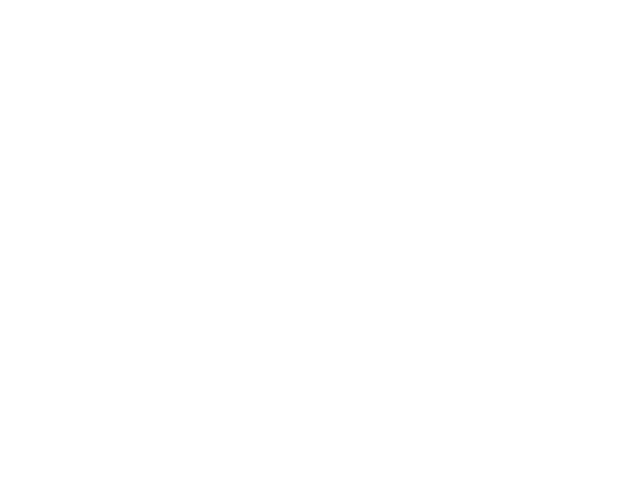

In [9]:
timestep = UnytTimeDelta(minutes=5)
# timestep = timedelta(minutes=5)

# Using the Pure Python implementation
convection = EmanuelConvectionPythonV3()
radiation_sw = RRTMGShortwave()
radiation_lw = RRTMGLongwave()
slab = SlabSurface()
simple_physics = SimplePhysics()

state = get_default_state([simple_physics, convection, radiation_lw, radiation_sw, slab])

def set_values(obj, val):
    if hasattr(obj, 'values'):
        obj.values[:] = val
    elif hasattr(obj, 'data'):
        obj.data[:] = val
    else:
        obj[:] = val

# state['air_temperature'].data[:] = 270
state['surface_albedo_for_direct_shortwave'].data[:] =  0.5
state['surface_albedo_for_direct_near_infrared'].data[:] = 0.5
state['surface_albedo_for_diffuse_shortwave'].data[:] = 0.5
state['zenith_angle'].data[:] = np.pi/2.5
state['surface_temperature'].data[:] = 300.
state['ocean_mixed_layer_thickness'].data[:] = 5
state['area_type'].data[:] = 'sea'

time_stepper = AdamsBashforth([convection, radiation_lw, radiation_sw, slab])
monitor = PlotFunctionMonitor(plot_function)
time_stepper.prognostic(state, timestep)

## Run Simulation

In [10]:
%matplotlib widget
for i in range(4000):
    convection.current_time_step = timestep
    print(state['air_temperature'].shape)
    diagnostics, state = time_stepper(state, timestep)
    state.update(diagnostics)
    print(state['air_temperature'].shape)
    
    diagnostics, new_state = simple_physics(state, timestep)
    print(state['air_temperature'].shape)
    state.update(diagnostics)
    state.update(new_state)
    
    if (i+1) % 20 == 0:
        monitor.store(state)
        print(f"Iteration {i+1}, Surface Temp: {get_data(state['surface_temperature']).flatten()[0]:.2f} K")
    
    state['time'] += timestep
    set_values(state['eastward_wind'], 3.0)

(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
Iteration 20, Surface Temp: 299.92 K
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1, 1)
(28, 1

KeyboardInterrupt: 

In [ ]:
convection(state)